<a href="https://colab.research.google.com/github/chrisanuo/chrisanuo/blob/main/Split_plot_Analysis_CN_Ratio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas openpyxl statsmodels scipy xlsxwriter patsy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.6 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Updated Working data_June 29_2026.xlsx to Updated Working data_June 29_2026.xlsx


In [3]:
import pandas as pd
import numpy as np

file_name = list(uploaded.keys())[0]

xls = pd.ExcelFile(file_name)

df = pd.concat(
    [pd.read_excel(file_name, sheet_name=s).assign(Depth=s) for s in xls.sheet_names],
    ignore_index=True
)

df = df.rename(columns={
    "Treatments": "Tillage",
    "crop-rotation": "Rotation",
    "Bulk C/N": "BulkCN",
    "POM C/N": "POMCN",
    "MAOM C/N": "MAOMCN",
    "Bulk (C/N)": "BulkCN",
    "POM(C/N)": "POMCN",
    "MAOM (C/N)": "MAOMCN"
})

df["Rep"] = df["Rep"].astype(str)

df["Tillage"] = df["Tillage"].replace({
    "MB plow": "Moldboard plow"
})

df["Rotation"] = df["Rotation"].replace({
    "C-C": "Continuous corn",
    "C-B": "Corn-soybean",
    "B-B": "Continuous soybean"
})

depth_order = ["0-5", "5-15", "15-30", "30-50", "50-75", "75-100"]
tillage_order = ["No-till", "Chisel plow", "Moldboard plow"]
rotation_order = ["Continuous corn", "Corn-soybean", "Continuous soybean"]

for v in ["BulkCN", "POMCN", "MAOMCN"]:
    df[v] = pd.to_numeric(df[v], errors="coerce")

In [5]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
from patsy import build_design_matrices
from scipy.stats import t
import itertools
import string

def lsmean_vector(model, rep_levels, rotation, tillage):
    design_info = model.model.data.design_info
    new = pd.DataFrame([
        {"Rep": rep, "Rotation": rotation, "Tillage": tillage}
        for rep in rep_levels
    ])
    X = build_design_matrices([design_info], new, return_type="dataframe")[0]
    return np.asarray(X.mean(axis=0))

def compact_letters(pair_sig, means):
    ordered = list(pd.Series(means).sort_values(ascending=False).index)
    letters = {g: "" for g in ordered}
    alphabet = list(string.ascii_lowercase)

    for g in ordered:
        for letter in alphabet:
            conflict = False
            for other in ordered:
                if letter in letters[other]:
                    pair = tuple(sorted([g, other]))
                    if pair_sig.get(pair, False):
                        conflict = True
                        break
            if not conflict:
                letters[g] += letter
                break
    return letters

def splitplot_analysis(var, label, alpha=0.05):
    anova_rows = []
    mean_rows = []
    pairwise_rows = []

    for depth in depth_order:
        sub = df[
            (df["Depth"] == depth) &
            (df["Tillage"].isin(tillage_order)) &
            (df["Rotation"].isin(rotation_order))
        ][["Rep", "Tillage", "Rotation", var]].dropna()

        if sub.empty:
            continue

        model = smf.ols(
            f"{var} ~ C(Rep) + C(Rep):C(Rotation) + C(Rotation)*C(Tillage)",
            data=sub
        ).fit()

        aov = sm.stats.anova_lm(model, typ=2)

        effects = {
            "C(Rotation)": "Crop rotation",
            "C(Tillage)": "Tillage intensity",
            "C(Rotation):C(Tillage)": "Crop rotation × Tillage intensity"
        }

        for term, effect in effects.items():
            if term in aov.index:
                anova_rows.append({
                    "Variable": label,
                    "Depth": depth,
                    "Effect": effect,
                    "df": aov.loc[term, "df"],
                    "F value": aov.loc[term, "F"],
                    "p value": aov.loc[term, "PR(>F)"],
                    "Significant p≤0.05": aov.loc[term, "PR(>F)"] <= alpha
                })

        rep_levels = sorted(sub["Rep"].unique())
        labels = []
        L = {}
        means = {}

        for till in tillage_order:
            for rot in rotation_order:
                group = f"{till} | {rot}"
                lv = lsmean_vector(model, rep_levels, rot, till)
                labels.append(group)
                L[group] = lv
                means[group] = float(lv @ model.params.values)

        cov = model.cov_params().values
        df_resid = model.df_resid
        pair_sig = {}

        for g1, g2 in itertools.combinations(labels, 2):
            diff_vec = L[g1] - L[g2]
            diff = means[g1] - means[g2]
            se = np.sqrt(max(float(diff_vec @ cov @ diff_vec.T), 0))
            tval = diff / se if se > 0 else np.nan
            pval = 2 * (1 - t.cdf(abs(tval), df_resid)) if se > 0 else np.nan
            sig = bool(pval <= alpha) if not np.isnan(pval) else False

            pair_sig[tuple(sorted([g1, g2]))] = sig

            pairwise_rows.append({
                "Variable": label,
                "Depth": depth,
                "Group 1": g1,
                "Group 2": g2,
                "LSMean difference": diff,
                "SE difference": se,
                "t value": tval,
                "df residual": df_resid,
                "p value": pval,
                "Significant p≤0.05": sig
            })

        letters = compact_letters(pair_sig, means)

        for group in labels:
            till, rot = group.split(" | ")
            vals = sub[
                (sub["Tillage"] == till) &
                (sub["Rotation"] == rot)
            ][var]

            mean_rows.append({
                "Variable": label,
                "Depth": depth,
                "Tillage": till,
                "Rotation": rot,
                "Observed mean": vals.mean(),
                "Observed SE": vals.std(ddof=1) / np.sqrt(len(vals)),
                "n": len(vals),
                "LSMean": means[group],
                "Fisher LSD letter": letters[group],
                "Mean ± SE": f"{vals.mean():.2f} ± {vals.std(ddof=1) / np.sqrt(len(vals)):.2f}"
            })

    return pd.DataFrame(anova_rows), pd.DataFrame(mean_rows), pd.DataFrame(pairwise_rows)

In [6]:
variables = [
    ("BulkCN", "Bulk soil C/N ratio"),
    ("POMCN", "POM C/N ratio"),
    ("MAOMCN", "MAOM C/N ratio")
]

anova_all = []
means_all = []
pairwise_all = []

for var, label in variables:
    aov, means, pairs = splitplot_analysis(var, label)
    anova_all.append(aov)
    means_all.append(means)
    pairwise_all.append(pairs)

anova_df = pd.concat(anova_all, ignore_index=True)
means_df = pd.concat(means_all, ignore_index=True)
pairwise_df = pd.concat(pairwise_all, ignore_index=True)

In [8]:
output_file = "CN_ratio_splitplot_ANOVA_Fisher_LSD_results.xlsx"

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    anova_df.to_excel(writer, sheet_name="ANOVA", index=False)
    means_df.to_excel(writer, sheet_name="Means_LSD_letters", index=False)
    pairwise_df.to_excel(writer, sheet_name="Pairwise_LSD", index=False)

files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
display(anova_df)

,Variable,Depth,Effect,df,F value,p value,Significant p≤0.05
0,Bulk soil C/N ratio,0-5,Crop rotation,2.0,2.731288,0.092060,False
1,Bulk soil C/N ratio,0-5,Tillage intensity,2.0,4.443069,0.027021,True
2,Bulk soil C/N ratio,0-5,Crop rotation × Tillage intensity,4.0,1.603361,0.216614,False
3,Bulk soil C/N ratio,5-15,Crop rotation,2.0,3.431462,0.054636,False
4,Bulk soil C/N ratio,5-15,Tillage intensity,2.0,4.604237,0.024273,True
5,Bulk soil C/N ratio,5-15,Crop rotation × Tillage intensity,4.0,0.228670,0.918716,False
6,Bulk soil C/N ratio,15-30,Crop rotation,2.0,0.308159,0.738598,False
7,Bulk soil C/N ratio,15-30,Tillage intensity,2.0,4.119989,0.033634,True
8,Bulk soil C/N ratio,15-30,Crop rotation × Tillage intensity,4.0,1.127791,0.374613,False
9,Bulk soil C/N ratio,30-50,Crop rotation,2.0,0.922823,0.415399,False


Next, here are the **LSMeans with Fisher LSD letters** (`means_df`). This table shows the observed mean, observed standard error (SE), the number of observations (n), the calculated LSMean, and the Fisher LSD letter for each combination of Tillage, Rotation, and Depth. Groups that do not share a common letter are significantly different from each other at the `alpha=0.05` level.

In [10]:
display(means_df)

,Variable,Depth,Tillage,Rotation,Observed mean,Observed SE,n,LSMean,Fisher LSD letter,Mean ± SE
0,Bulk soil C/N ratio,0-5,No-till,Continuous corn,13.393532,0.210276,4,13.393532,a,13.39 ± 0.21
1,Bulk soil C/N ratio,0-5,No-till,Corn-soybean,13.830623,0.803460,4,13.830623,a,13.83 ± 0.80
2,Bulk soil C/N ratio,0-5,No-till,Continuous soybean,14.814254,1.244298,4,14.814254,a,14.81 ± 1.24
3,Bulk soil C/N ratio,0-5,Chisel plow,Continuous corn,10.808496,1.236405,4,10.808496,b,10.81 ± 1.24
4,Bulk soil C/N ratio,0-5,Chisel plow,Corn-soybean,13.070641,0.671005,4,13.070641,a,13.07 ± 0.67
...,...,...,...,...,...,...,...,...,...,...
148,MAOM C/N ratio,50-75,Chisel plow,Corn-soybean,18.589825,0.551448,4,18.589825,a,18.59 ± 0.55
149,MAOM C/N ratio,50-75,Chisel plow,Continuous soybean,13.126171,2.986130,4,13.126171,a,13.13 ± 2.99
150,MAOM C/N ratio,50-75,Moldboard plow,Continuous corn,17.185735,1.018312,4,17.185735,a,17.19 ± 1.02
151,MAOM C/N ratio,50-75,Moldboard plow,Corn-soybean,15.582541,3.244886,4,15.582541,a,15.58 ± 3.24


### Visualization of MAOM C/N Ratio LSMeans

Below are grouped bar plots showing the Least Squares Means (LSMeans) for 'MAOM C/N ratio' across different depths. Each plot displays the interaction between Tillage and Rotation. The letters above the bars are Fisher LSD letters: groups that do not share a common letter within the same depth are significantly different at the alpha=0.05 level.

/tmp/ipykernel_9909/564576000.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Tillage', loc='upper right')


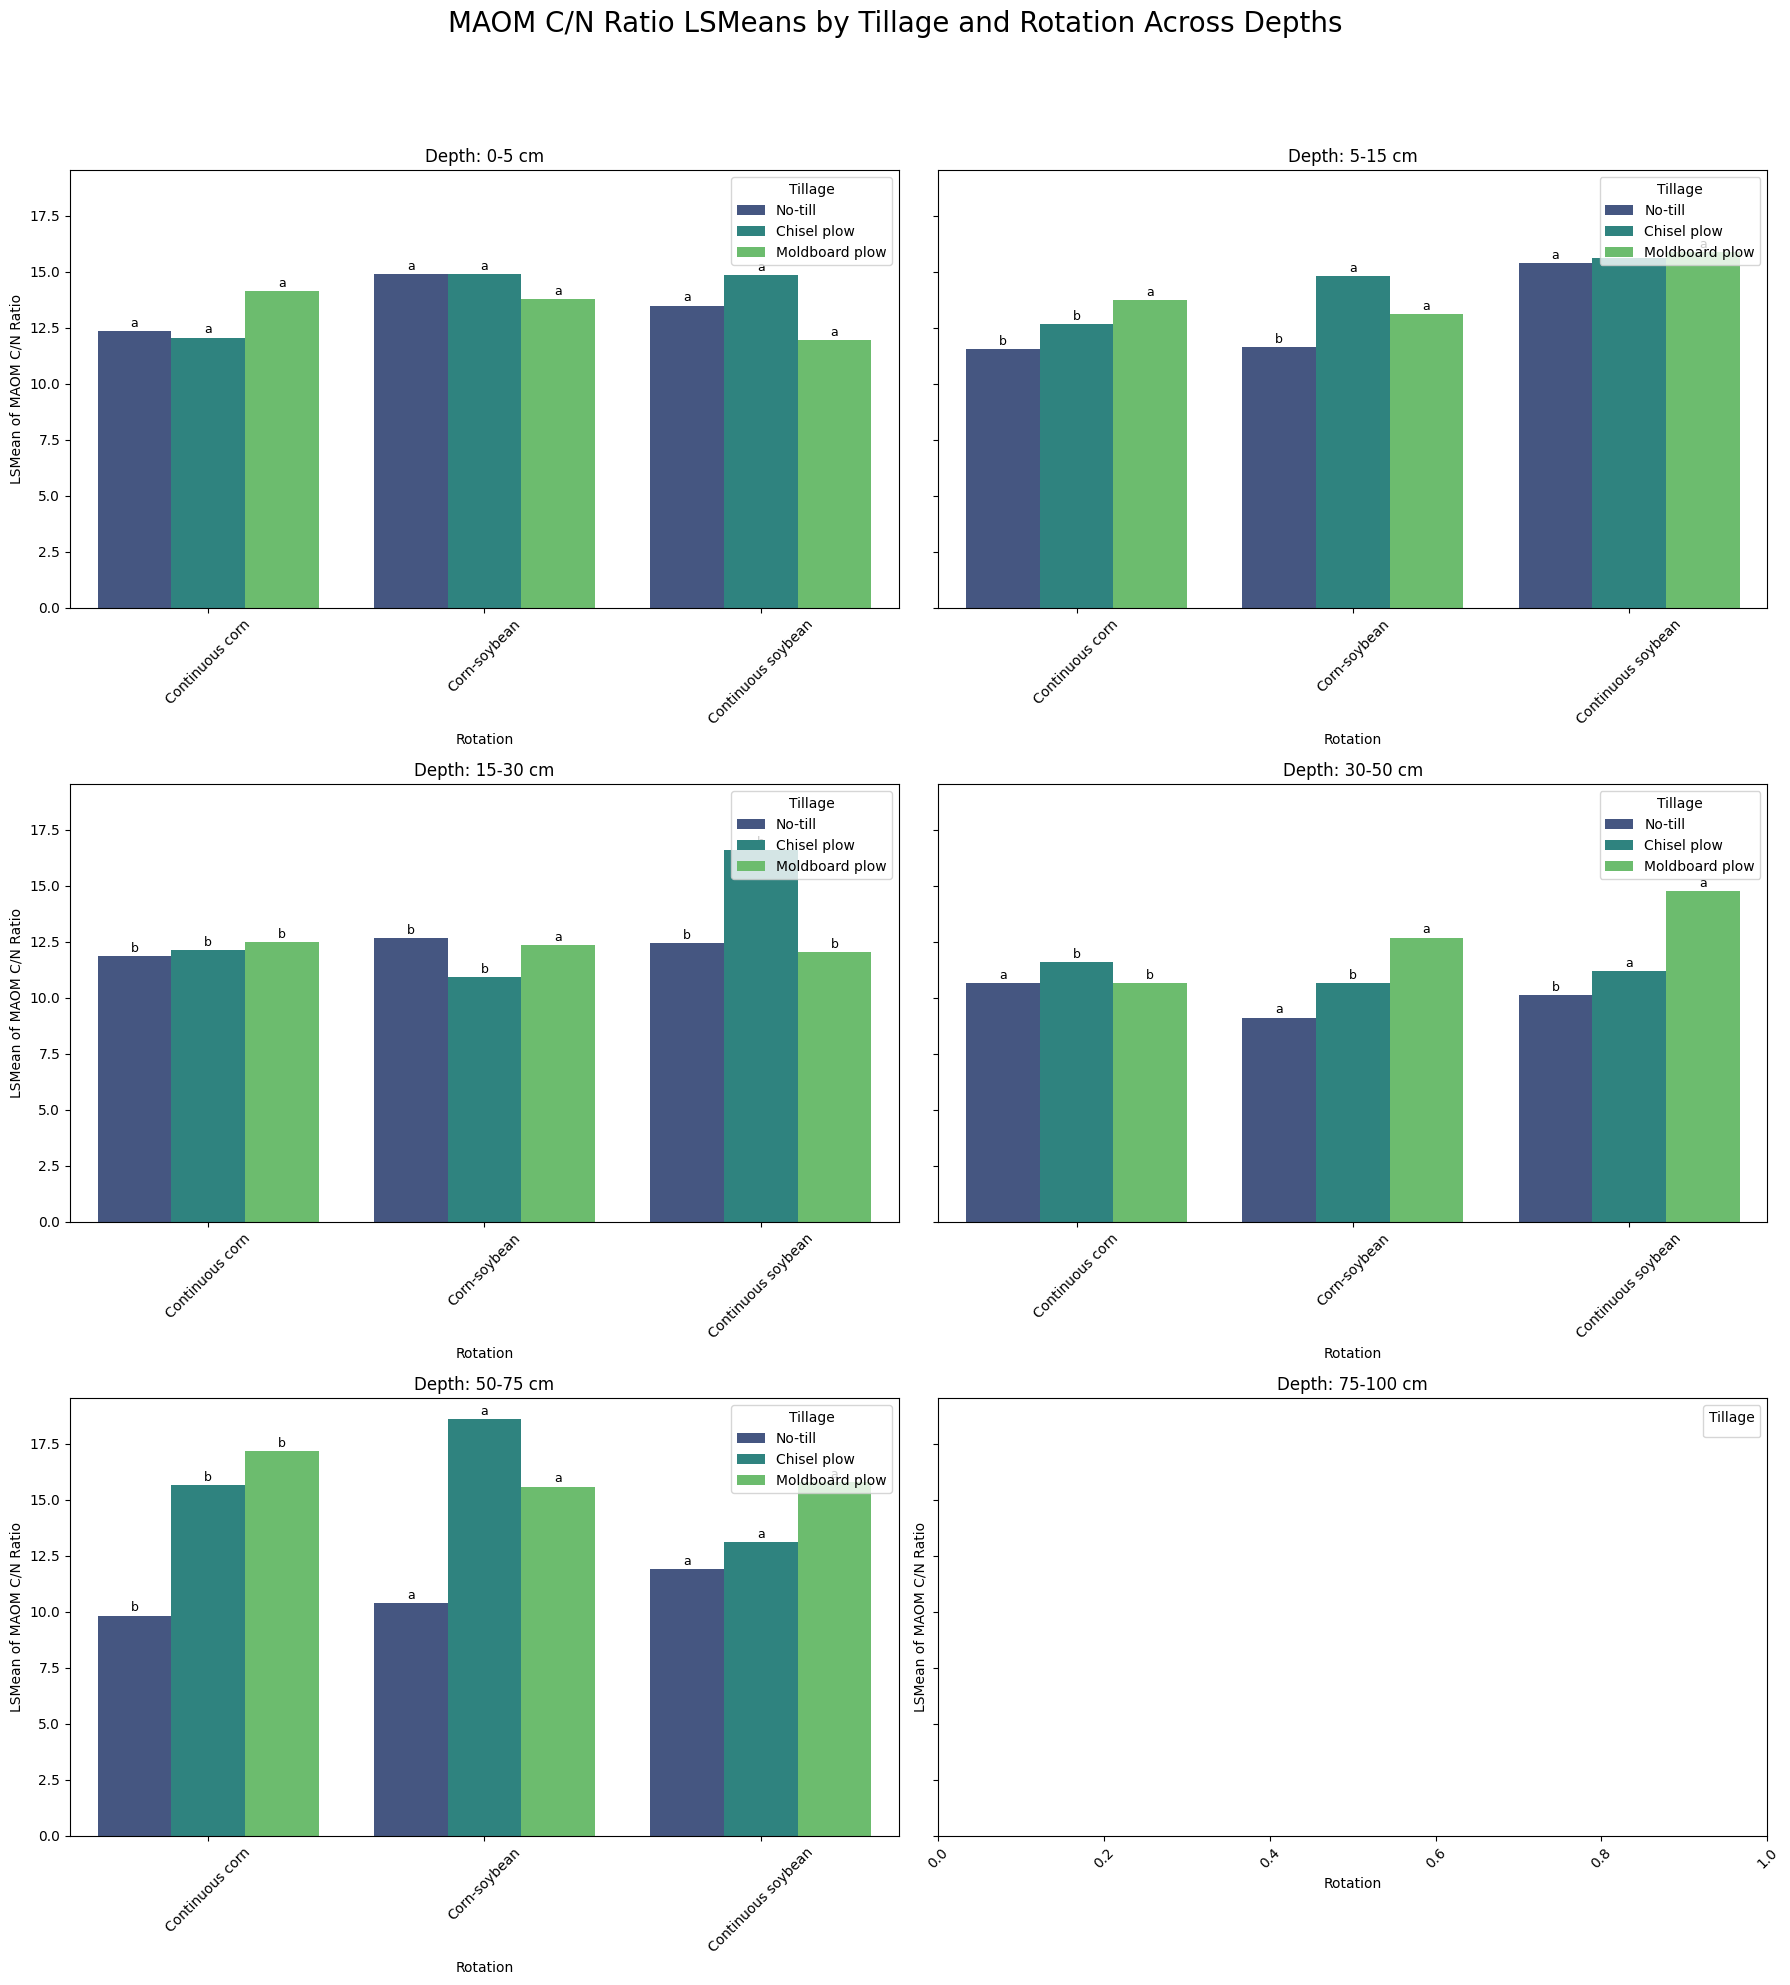

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter means_df for MAOM C/N ratio
maom_means = means_df[means_df['Variable'] == 'MAOM C/N ratio']

# Set up the figure and subplots for 6 depths (3 rows, 2 columns)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 20), sharey=True)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

fig.suptitle('MAOM C/N Ratio LSMeans by Tillage and Rotation Across Depths', fontsize=20, y=1.02)

for i, depth in enumerate(depth_order):
    ax = axes[i]
    depth_data = maom_means[maom_means['Depth'] == depth]

    # Sort depth_data to ensure consistent order for annotations
    depth_data_sorted = depth_data.sort_values(
        by=['Rotation', 'Tillage'],
        key=lambda x: x.map(
            {v: idx for idx, v in enumerate(rotation_order)} if x.name == 'Rotation' else \
            {v: idx for idx, v in enumerate(tillage_order)}
        )
    )

    sns.barplot(
        data=depth_data_sorted,
        x='Rotation',
        y='LSMean',
        hue='Tillage',
        ax=ax,
        palette='viridis',
        order=rotation_order,
        hue_order=tillage_order
    )

    ax.set_title(f'Depth: {depth} cm')
    ax.set_xlabel('Rotation')
    ax.set_ylabel('LSMean of MAOM C/N Ratio')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Tillage', loc='upper right')

    # Add Fisher LSD letters as annotations
    for p, (index, row) in zip(ax.patches, depth_data_sorted.iterrows()):
        # Get the height of the bar
        height = p.get_height()
        # Place the text slightly above the bar
        ax.text(p.get_x() + p.get_width() / 2., height + 0.05, # Adjust 0.05 as needed for spacing
                f'{row["Fisher LSD letter"]}',
                ha='center', va='bottom', fontsize=9, color='black')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make space for suptitle
plt.show()

In [13]:
# @title step_artifacts
# To save the generated figure, you can use the following code.
# This assumes `fig` is the latest matplotlib figure object.

# Ensure the figure object from the previous cell is accessible.
# If not, you might need to re-run the plotting code in a single cell
# with this saving part. For now, we'll assume `fig` is the current figure.

# To save the current figure
output_figure_path = "MAOM_CN_Ratio_LSMeans_by_Depth.png"
fig.savefig(output_figure_path, dpi=300, bbox_inches='tight')
print(f"Figure saved to {output_figure_path}")

Figure saved to MAOM_CN_Ratio_LSMeans_by_Depth.png


The `pairwise_df` contains all the detailed pairwise comparison results, which can be quite extensive. If you need to inspect specific pairwise comparisons, let me know, and I can show you a filtered view of that DataFrame.